In [36]:
import cv2
import numpy as np
from pathlib import Path


def classify_painting_type(img_rgb):
    """
    Returns: 'charcoal', 'red', or 'unknown'
    """

    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)

    H, S, V = cv2.split(hsv)
    L, A, B = cv2.split(lab)

    # --- rouge mask HSV ---
    red_mask1 = (H < 10) & (S > 60) & (V > 50)
    red_mask2 = (H > 170) & (S > 60) & (V > 50)
    red_mask = red_mask1 | red_mask2

    # --- rouge mask Lab ---
    red_lab_mask = A > 150

    red_score = np.mean(red_mask | red_lab_mask)

    # --- charbon mask ---
    dark_mask = (V < 80) & (S < 60)
    charcoal_score = np.mean(dark_mask)
    # print(charcoal_score)
    # print(red_score)
    
    return red_score, charcoal_score

    # --- décision ---
    if red_score > 0.08 and charcoal_score>0.01:
        return "red and charcoal"
    elif charcoal_score > 0.01:
        return "charcoal"
    elif red_score > 0.08:
        return "red"
    else:
        return "unknown"



In [37]:
img_dir = Path("dataset")   # CHANGE THIS

paths = list(img_dir.glob("**/*.jpg"))
print(paths)

images = []
for p in paths:
    print(p)
    bgr = cv2.imread(str(p))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    print(classify_painting_type(rgb))

[WindowsPath('dataset/altamira/Cueva_de_Altamira-19621007-001.jpg'), WindowsPath('dataset/altamira/Cueva_de_Altamira-19621007-002.jpg'), WindowsPath('dataset/altamira/Cueva_de_Altamira-19621007-003.jpg'), WindowsPath('dataset/altamira/Techo_de_Altamira_replica-Museo_Arqueologico_Nacional.jpg'), WindowsPath('dataset/chauvet/owl-engraving-chauvet-cave-replica-6348.jpg'), WindowsPath('dataset/chauvet/panel-of-the-horses-chauvet-cave-replica-6349.jpg'), WindowsPath('dataset/chauvet/panel-of-the-lions-detail-chauvet-cave-6345.jpg'), WindowsPath('dataset/chauvet/panel-of-the-rhinos-chauvet-cave-replica-6350.jpg'), WindowsPath('dataset/chauvet/red-dots-cluster-chauvet-cave-replica-6347.jpg'), WindowsPath('dataset/cosquer/Panneau_des_chevaux_-_Cosquer_Mediterranee.jpg'), WindowsPath('dataset/gravures/08_ChevalGravureAuDoigt.jpg'), WindowsPath('dataset/gravures/27_DeuxMamouthsGravureAuDoigt.jpg'), WindowsPath('dataset/lascaux/Lascaux,_replica_03.JPG'), WindowsPath('dataset/lascaux/Lascaux_001.j

In [38]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path

# -------------------------
# Classifier avec seuils paramétrables
# -------------------------
def classify_painting_type(img_rgb, red_th=0.08, charcoal_th=0.01):

    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)

    H, S, V = cv2.split(hsv)
    L, A, B = cv2.split(lab)

    red_mask1 = (H < 10) & (S > 60) & (V > 50)
    red_mask2 = (H > 170) & (S > 60) & (V > 50)
    red_mask = red_mask1 | red_mask2

    red_lab_mask = A > 150
    red_score = np.mean(red_mask | red_lab_mask)

    dark_mask = (V < 80) & (S < 60)
    charcoal_score = np.mean(dark_mask)

    if red_score > red_th:
        return "red"
    else:
        return "charcoal"


# -------------------------
# Chargement dataset
# -------------------------
def load_dataset(root):

    data = []

    mapping = {
        "noir": "charcoal",
        "rouge": "red"
    }

    for folder, label in mapping.items():
        d = Path(root) / folder
        for p in d.glob("*"):
            if p.suffix.lower() in [".jpg", ".png", ".jpeg"]:
                data.append((str(p), label))

    return data


# -------------------------
# Evaluation
# -------------------------
def evaluate(root, red_th, charcoal_th):

    dataset = load_dataset(root)

    y_true = []
    y_pred = []

    for path, label in dataset:
        bgr = cv2.imread(path)
        if bgr is None:
            continue

        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

        pred = classify_painting_type(rgb, red_th, charcoal_th)

        y_true.append(label)
        y_pred.append(pred)

    labels = ["charcoal", "red"]

    cm = pd.crosstab(
        pd.Series(y_true, name="true"),
        pd.Series(y_pred, name="pred"),
        dropna=False
    ).reindex(index=labels, columns=labels, fill_value=0)

    acc = np.mean([t == p for t, p in zip(y_true, y_pred)])

    recall = cm.div(cm.sum(axis=1), axis=0)

    return acc, cm, recall


# -------------------------
# Grid search seuils
# -------------------------
def grid_search(root):

    results = []

    for red_th in np.linspace(0.02, 0.15, 10):
        for char_th in np.linspace(0.005, 0.05, 10):
            
            print(red_th, char_th)

            acc, cm, recall = evaluate(root, red_th, char_th)
            results.append((red_th, char_th, acc, cm, recall))

    df = pd.DataFrame(
        results,
        columns=["red_th", "charcoal_th", "accuracy", "cm", "recall"]
    )

    return df.sort_values("accuracy", ascending=False)


In [39]:
df = grid_search("classif_dataset")
df.head(10)


0.02 0.005
0.02 0.010000000000000002
0.02 0.015000000000000003
0.02 0.020000000000000004
0.02 0.025000000000000005
0.02 0.030000000000000006
0.02 0.035
0.02 0.04
0.02 0.045000000000000005
0.02 0.05
0.034444444444444444 0.005
0.034444444444444444 0.010000000000000002
0.034444444444444444 0.015000000000000003
0.034444444444444444 0.020000000000000004
0.034444444444444444 0.025000000000000005
0.034444444444444444 0.030000000000000006
0.034444444444444444 0.035
0.034444444444444444 0.04
0.034444444444444444 0.045000000000000005
0.034444444444444444 0.05
0.04888888888888889 0.005
0.04888888888888889 0.010000000000000002
0.04888888888888889 0.015000000000000003
0.04888888888888889 0.020000000000000004
0.04888888888888889 0.025000000000000005
0.04888888888888889 0.030000000000000006
0.04888888888888889 0.035
0.04888888888888889 0.04
0.04888888888888889 0.045000000000000005
0.04888888888888889 0.05
0.06333333333333334 0.005
0.06333333333333334 0.010000000000000002
0.06333333333333334 0.0150000

,red_th,charcoal_th,accuracy,cm,recall
87,0.135556,0.040,0.763158,pred charcoal red true ...,pred charcoal red true ...
86,0.135556,0.035,0.763158,pred charcoal red true ...,pred charcoal red true ...
85,0.135556,0.030,0.763158,pred charcoal red true ...,pred charcoal red true ...
84,0.135556,0.025,0.763158,pred charcoal red true ...,pred charcoal red true ...
96,0.150000,0.035,0.763158,pred charcoal red true ...,pred charcoal red true ...
97,0.150000,0.040,0.763158,pred charcoal red true ...,pred charcoal red true ...
98,0.150000,0.045,0.763158,pred charcoal red true ...,pred charcoal red true ...
99,0.150000,0.050,0.763158,pred charcoal red true ...,pred charcoal red true ...
95,0.150000,0.030,0.763158,pred charcoal red true ...,pred charcoal red true ...
94,0.150000,0.025,0.763158,pred charcoal red true ...,pred charcoal red true ...


In [44]:
acc, cm, recall = evaluate(
    "classif_dataset",
    red_th=0.135556,
    charcoal_th=0.04
)


print("accuracy:", acc)
print(cm)
print("recall:")
print(recall)


accuracy: 0.7631578947368421
pred      charcoal  red
true                   
charcoal        21    6
red              3    8
recall:
pred      charcoal       red
true                        
charcoal  0.777778  0.222222
red       0.272727  0.727273


In [45]:
def compute_scores(img_rgb):

    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)

    H, S, V = cv2.split(hsv)
    L, A, B = cv2.split(lab)

    red_mask1 = (H < 10) & (S > 60) & (V > 50)
    red_mask2 = (H > 170) & (S > 60) & (V > 50)
    red_mask = red_mask1 | red_mask2

    red_lab_mask = A > 150

    red_score = np.mean(red_mask | red_lab_mask)

    dark_mask = (V < 80) & (S < 60)
    charcoal_score = np.mean(dark_mask)

    return red_score, charcoal_score

def classify_with_scores(img_rgb, red_th, charcoal_th):

    red_score, charcoal_score = compute_scores(img_rgb)

    if red_score > red_th:
        pred = "red"
    else:
        pred = "charcoal"

    return pred, red_score, charcoal_score

def evaluate_with_errors(root, red_th, charcoal_th):

    dataset = load_dataset(root)

    rows = []

    for path, label in dataset:
        print(path)
        bgr = cv2.imread(path)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

        pred, rs, cs = classify_with_scores(rgb, red_th, charcoal_th)

        rows.append({
            "path": path,
            "true": label,
            "pred": pred,
            "red_score": rs,
            "charcoal_score": cs
        })

    df = pd.DataFrame(rows)

    cm = pd.crosstab(df.true, df.pred)

    acc = (df.true == df.pred).mean()

    errors = df[df.true != df.pred]

    return df, cm, acc, errors



In [49]:
df_res, cm, acc, errors = evaluate_with_errors(
    "classif_dataset",
    red_th=0.135556,
    charcoal_th=0.04
)

print("Accuracy:", acc)
print(cm)


classif_dataset\noir\10-LAS-SdT-Paroi-Gauche_N-Aujoulat-Centre-National-de-Preuhistoire-MinisteCre-de-la-Culture-et-de-la-Communication-1800x499.png
classif_dataset\noir\2015-04-08T160550Z_168532498_PM1EB48155V01_RTRMADP_3_FRANCE-CULTURE.jpg
classif_dataset\noir\2_grotte_cosquer_chevaux_mcc-drac-sra_paca.michel_olive_0.jpg
classif_dataset\noir\41a6442-640x480-crop-1664181161.jpg
classif_dataset\noir\5589.jpg
classif_dataset\noir\5d7a6f9b7295b.image.jpg
classif_dataset\noir\5_grotte_cosquer_pingouins_mcc-drac-sra_paca.michel_olive.jpg
classif_dataset\noir\6350.jpg
classif_dataset\noir\695806.jpg
classif_dataset\noir\a9eab1f6efd7c1da733551b5aaa89284-1920x1251.jpg
classif_dataset\noir\cda2022_grotte_cosquer_marseille_panneau-des-pingouins-salle-nord-tt-width-620-height-465-fill-0-crop-0-bgcolor-eeeeee.jpg
classif_dataset\noir\chauvetbison_new1.jpg
classif_dataset\noir\dreamstime_m_299152358.jpg
classif_dataset\noir\images (2).jpg
classif_dataset\noir\images (3).jpg
classif_dataset\noir\im

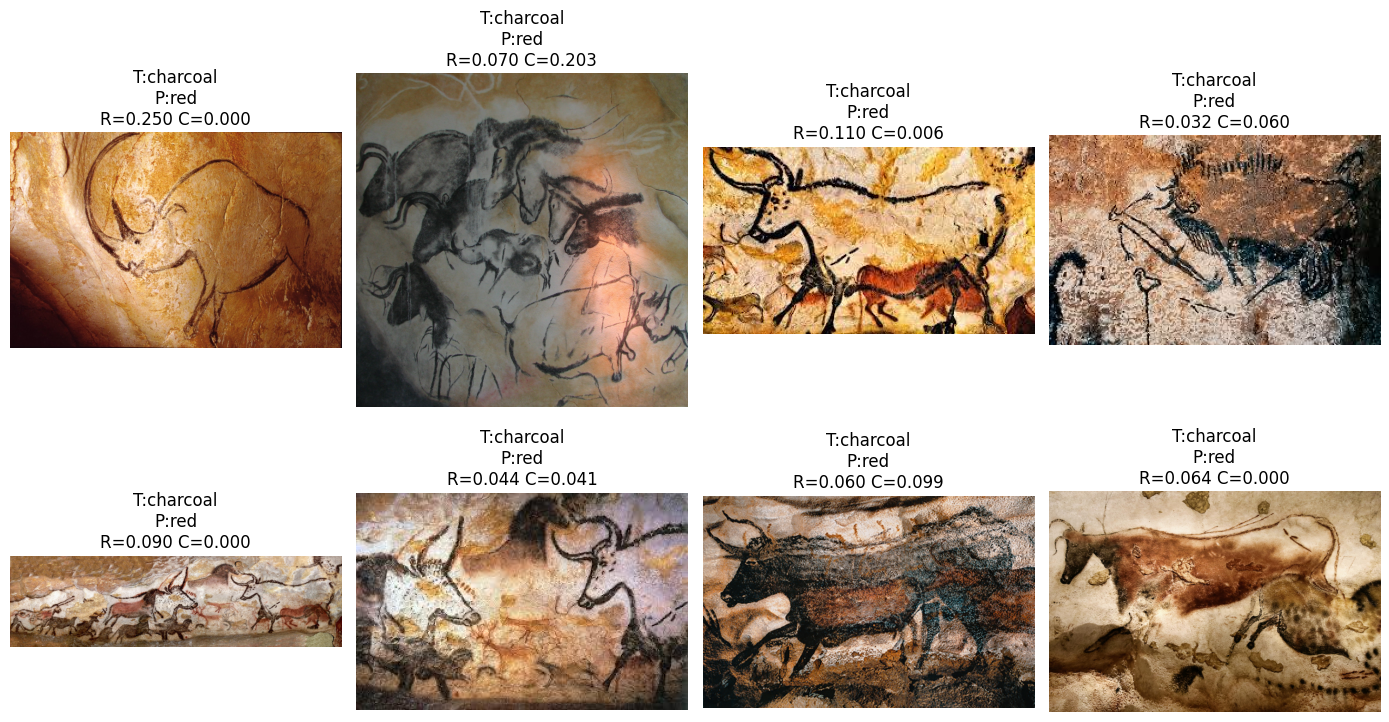

true      pred
charcoal  red     19
dtype: int64

In [48]:
import matplotlib.pyplot as plt

def show_errors(errors_df, n=8):

    sample = errors_df.sample(min(n, len(errors_df)))

    plt.figure(figsize=(14, 8))

    for i, row in enumerate(sample.itertuples(), 1):

        bgr = cv2.imread(row.path)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 4, i)
        plt.imshow(rgb)
        plt.axis("off")

        plt.title(
            f"T:{row.true}\nP:{row.pred}\n"
            f"R={row.red_score:.3f} C={row.charcoal_score:.3f}"
        )

    plt.tight_layout()
    plt.show()

show_errors(errors, n=8)

errors.groupby(["true","pred"]).size()



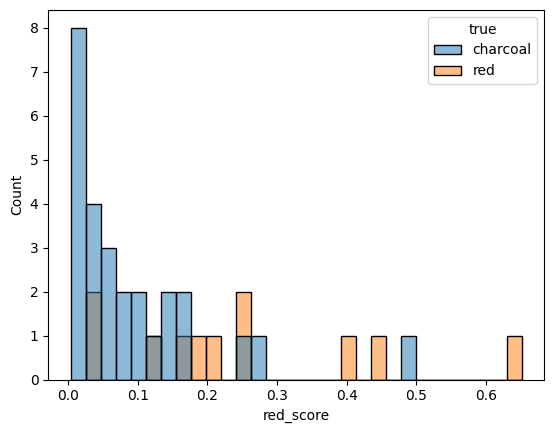

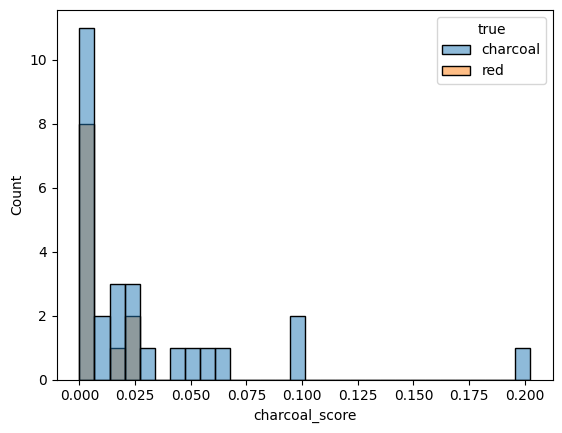

In [50]:
import seaborn as sns

sns.histplot(data=df_res, x="red_score", hue="true", bins=30)
plt.show()

sns.histplot(data=df_res, x="charcoal_score", hue="true", bins=30)
plt.show()
